In [21]:
# include all functions
include("FUNCTIONS/coordinates.jl")
include("FUNCTIONS/Satellite.jl")
include("FUNCTIONS/J2.jl")
include("FUNCTIONS/Pertubations.jl")
include("FUNCTIONS/Propagation.jl")
include("FUNCTIONS/Results.jl")
include("FUNCTIONS/Rotations.jl")
include("FUNCTIONS/Satellite.jl")
include("FUNCTIONS/SolveKepler.jl")
include("FUNCTIONS/Time.jl")
include("HW2/Pertubations.jl")
include("Analysis/Summary.jl")
include("Analysis/OrbitalElements.jl")
include("FUNCTIONS/RepeatOrbit.jl")
include("Analysis/RepeatAnalysis.jl")
include("FUNCTIONS/state.jl")



compute_state (generic function with 1 method)

In [94]:
i_demo = deg2rad(68)

a_repeat = design_repeat_orbit(1, 15, i_demo,
    a_low = 2000.0,
    a_high = 10000.0
)

sat = Satellite(
    "Repeat Orbit",
    a_repeat,
    0.0,
    i_demo,
    0.0,
    0.0,
    0.0
)

Satellite("Repeat Orbit", 6893.409267242532, 0.0, 1.1868238913561442, 0.0, 0.0, 0.0)

In [95]:
rad2deg(i_demo)

68.0

In [96]:
# Earth Constants
GM = 398600.4418          # km³/s²
ωE = 7.2921150e-5         # rad/s

7.292115e-5

In [97]:
result = propagate_j2(
    sat,
    GM,
    ωE;
    dt = 30.0,
    revolutions = 2
)
summary(result)


================== PROPAGATION SUMMARY ==================

Satellite              : Repeat Orbit
Propagator             : Analytical J2_stateupdated
Time Step              : 30.0 s
Revolutions            : 2
Propagation Time       : 11370.0 s (3.16 hr)
Stored Epochs          : 380

---------------------------------------------------------
Initial Orbital Elements
---------------------------------------------------------
a = 6893.409267242532 km
e = 0.0
i = 68.0°
Ω = 0.0°
ω = 0.0°
M = 0.0°

---------------------------------------------------------
Final Orbital Elements
---------------------------------------------------------
a = 6893.409267242532 km
e = 0.0
i = 68.0°
Ω = -0.374255°
ω = -0.149035°
M = 718.333397°

---------------------------------------------------------
Element Changes
---------------------------------------------------------
Δa = 0.0 km
Δe = 0.0
Δi = 0.0°
ΔΩ = -0.374255°
Δω = -0.149035°
ΔM = 718.333397°


In [98]:
dt=30.0
revolutions = 2
T = orbital_period(sat.a, GM)

t_list = collect(0.0:dt:revolutions*T)

380-element Vector{Float64}:
     0.0
    30.0
    60.0
    90.0
   120.0
   150.0
   180.0
   210.0
   240.0
   270.0
   300.0
   330.0
   360.0
     ⋮
 11040.0
 11070.0
 11100.0
 11130.0
 11160.0
 11190.0
 11220.0
 11250.0
 11280.0
 11310.0
 11340.0
 11370.0

In [99]:
println(last(t_list))
println(revolutions*T)
println(last(t_list)-revolutions*T)

11370.0
11391.792655232348
-21.792655232347897


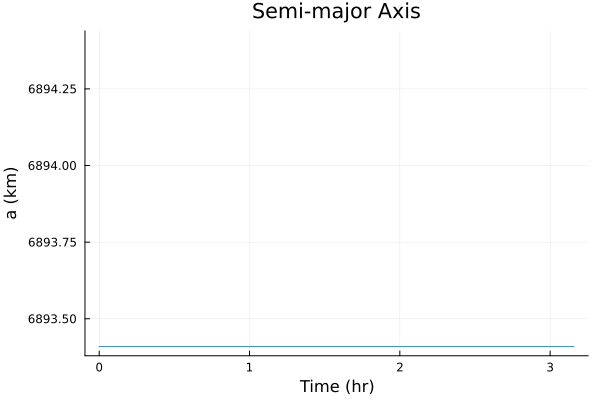

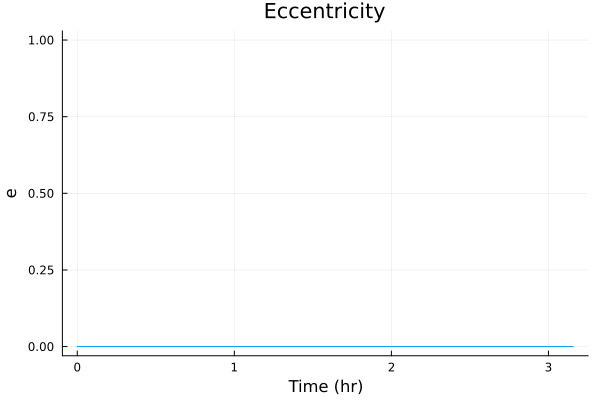

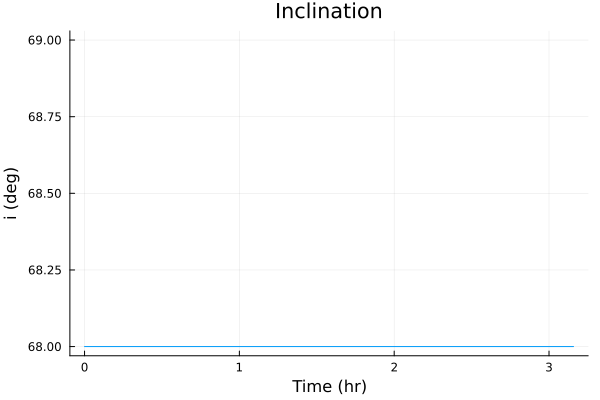

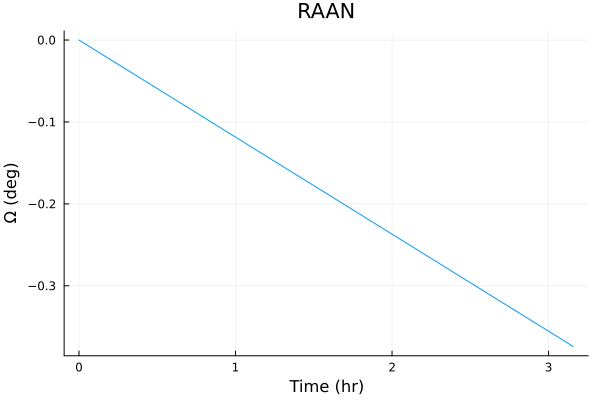

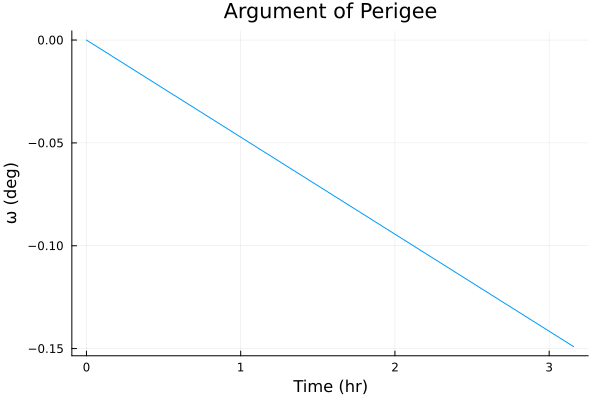

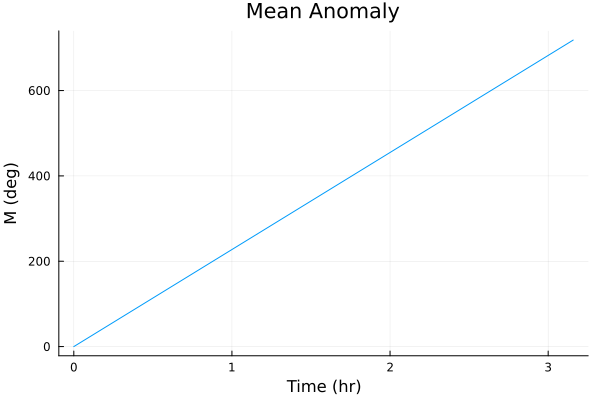

In [100]:
plots = plot_orbital_elements(result)
for p in plots
    display(p)
end

In [101]:
savefig(plots[5], "/home/Arpan/orbit/Figures/AOP(i=68).png")

"/home/Arpan/orbit/Figures/AOP(i=68).png"

In [84]:
savefig(plots[1], "Figures/a1.png")
savefig(plots[2], "Figures/e1.png")
savefig(plots[3], "Figures/i1.png")
savefig(plots[4], "Figures/RAAN1.png")
savefig(plots[5], "Figures/AOP1.png")
savefig(plots[6], "Figures/MeanAnomaly1.png")

"/home/Arpan/orbit/Figures/MeanAnomaly1.png"

In [9]:
i_demo = deg2rad(60.0)

a_repeat = design_repeat_orbit(1, 15, i_demo)

sat = Satellite(
    "Repeat Orbit",
    a_repeat,
    0.0,
    i_demo,
    0.0,
    0.0,
    0.0
)

result = propagate_j2(
    sat,
    GM,
    ωE;
    dt = 1.0,
    revolutions = 30,
    repeat_revolutions = 15
)

PropagationResult("Analytical J2", 1.0, 30, "Repeat Orbit", 15, [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0  …  5709.0, 5710.0, 5711.0, 5712.0, 5713.0, 5714.0, 5715.0, 5716.0, 5717.0, 5718.0], [715.8768157940358 715.51140368488 … 660.3312256919714 656.9052698659423; 0.0 10.276067493471716 … 274.54488216396476 284.26223290391545; 0.0 20.431569327151827 … -32.6710184279769 -12.25009217277983], [0.0 -0.7525930239115378 … -3.6733412326824055 -4.3653615894059925; 11.79830837826101 11.793525153364477 … 11.263496421688593 10.968442987553532; 20.43526955451363 20.424169274452627 … 20.406874697049012 20.431279915284364], [715.8768157940358 715.5121511251745 … 714.9439860479181 715.7457491536026; 0.0 10.223891551801676 … -16.349824470033013 -6.129698337968648; 0.0 20.431569327151827 … -32.6710184279769 -12.25009217277983], [0.0, 1.635479249448556, 3.270513554106661, 4.904655183307936, 6.537450802938001, 8.16843859399193, 9.797145274125228, 11.423082987607664, 13.045746027126905, 14.6646073

Checking the repeat condition

In [10]:
a_repeat
L, r, e = repeat_condition(
    a_repeat,
    0.0,
    i_demo,
    1.0,
    15.0;
    μ = 398600.4418,
    Re = 6378.137,
    J2 = 1.08263e-3,
    ωE = 7.292115e-5
)

(15.000000000035644, 15.0, 3.5644376339405426e-11)

In [11]:
α = 1
β = 15
T = orbital_period(sat.a, GM)

T_repeat = β * T

2859.2997486627182

In [13]:
sat_end = propagate_j2_elements(sat, T_repeat)

Satellite("Repeat Orbit", 715.8768157940358, 0.0, 1.0471975511965976, -6.07468188129746, 1.5186704703243674, 92.72910913736942)

In [14]:
Ωdot, ωdot, Mdot = compute_j2_secular_rates(
    sat.a,
    sat.e,
    sat.i
)

println("Expected ΔΩ = ", Ωdot * T_repeat)
println("Expected Δω = ", ωdot * T_repeat)
println("Expected ΔM = ", Mdot * T_repeat)

Expected ΔΩ = -6.07468188129746
Expected Δω = 1.5186704703243674
Expected ΔM = 92.72910913736942


In [15]:
println("Actual ΔΩ = ", sat_end.Ω - sat.Ω)
println("Actual Δω = ", sat_end.ω - sat.ω)
println("Actual ΔM = ", sat_end.M0 - sat.M0)

Actual ΔΩ = -6.07468188129746
Actual Δω = 1.5186704703243674
Actual ΔM = 92.72910913736942


In [16]:
Ωdot, ωdot, Mdot = compute_j2_secular_rates(sat.a, sat.e, sat.i)

println("Mean motion ratio:")
println((Mdot + ωdot) / (ωE - Ωdot))

println("Satellite revolutions in one repeat cycle:")
println((Mdot + ωdot) * T_repeat / (2π))

println("Earth relative rotation in one repeat cycle:")
println((ωE - Ωdot) * T_repeat / (2π))

Mean motion ratio:
15.000000000035644
Satellite revolutions in one repeat cycle:
15.000000000000002
Earth relative rotation in one repeat cycle:
0.9999999999976238


In [12]:
T = orbital_period(sat.a, GM)

samples_per_rev = round(Int, T / result.dt)

samples_per_cycle = result.repeat_revolutions * samples_per_rev + 1

println("Samples per revolution = ", samples_per_rev)
println("Samples per cycle = ", samples_per_cycle)

Samples per revolution = 191
Samples per cycle = 2866


In [10]:
T = orbital_period(sat.a, GM)

for k in [0, 15]

    t_exact = k*T

    idx = argmin(abs.(result.time .- t_exact))

    println("k = $k")
    println("Exact time   = ", t_exact)
    println("Nearest time = ", result.time[idx])
    println("Index        = ", idx)
    println()

end

k = 0
Exact time   = 0.0
Nearest time = 0.0
Index        = 1

k = 15
Exact time   = 85263.21988870557
Nearest time = 85263.0
Index        = 85264



In [11]:
idx1 = argmin(abs.(result.time .- 0.0))
idx2 = argmin(abs.(result.time .- 15*T))

println(result.positions_ecef[:, idx1])
println(result.positions_ecef[:, idx2])

println(norm(result.positions_ecef[:, idx1] -
             result.positions_ecef[:, idx2]))

[6883.980950588011, 0.0, 0.0]
[6883.98075989523, -0.7250602539565989, -1.4490474535949573]
1.620324328954353


In [12]:
cycles, rms_errors, max_errors = closure_error(result)
println("Cycles: ", cycles)
println("RMS Errors: ", rms_errors)
println("Max Errors: ", max_errors)

println(length(cycles))
println(length(rms_errors))
println(length(max_errors))

Orbital Period = 5684.2
Samples per Revolution = 5684
Samples per Cycle = 85261
Number of Repeat Cycles = 2
Reference Size = (3, 85261)

------------------------------
Cycle 2
------------------------------
Start Index = 85261
Stop Index  = 170521
Current Size = (3, 85261)
Start Time = 85260.0
Stop Time  = 170520.0
Distances = [23.726827307584195, 23.726827421919957, 23.72682743330324, 23.72682734154408, 23.726827146737794, 23.726826848983233, 23.726826448086246, 23.726825944244396, 23.726825337264565, 23.726824627342523, 23.726823814291667, 23.726822898211086, 23.72682187920262, 23.726820757076155, 23.72681953203248, 23.726818203882075, 23.726816772824186, 23.72681523867596, 23.726813601539575, 23.726811861520808, 23.726810018432722, 23.72680807247987, 23.726806023476243, 23.72680387162437, 23.72680161674499, 23.72679925894392, 23.726796798330458, 23.726794234721147, 23.726791568323723, 23.726788798956182, 23.726785926726702, 23.726782951752355, 23.726779873849882, 23.726776693229173,

Excessive output truncated after 524299 bytes.

 23.68986147605097, 23.6898307356006, 23.689800072982173, 23.689769488105373, 23.689738981237742, 23.689708552652785, 23.689678202255312, 23.68964793041349, 23.689617737104946, 23.689587622518253, 23.68955758693787, 23.689527630309613, 23.689497752996598, 23.68946795490465, 23.689438236398626, 23.68940859745188, 23.689379038259045, 23.689349559086384, 23.68932015990853, 23.68929084101469, 23.68926160237953, 23.689232444340433, 23.689203366867627, 23.689174370148212, 23.689145454458234, 23.68911661976231, 23.689087866346807, 23.68905919418429, 23.68903060360946, 23.689002094589323, 23.688973667314738, 23.68894532204646, 23.688917058752327, 23.68888887771637, 23.68886077890613, 23.688832762681542, 23.68880482893107, 23.68877697791137, 23.688749209866465, 23.688721524758055, 23.688693922863184, 23.688666404151736, 23.688638968975486, 23.688611617223284, 23.688584349154183, 23.688557165021315, 23.688530064717053, 23.6885030485896,

In [13]:
println(result.time[1])
println(result.time[136])
println(result.time[137])
println(result.time[end])
println(length(result.time))
println(size(result.positions_ecef))

0.0
135.0
136.0
170526.0
170527
(3, 170527)
